# Spotify Music Recommendation System: Accuracy vs Novelty

This project compares recommendation models using a Spotify music taste dataset. The target variable is `liked`, which is treated as a binary indicator of whether a user liked a song. The project compares recommendation accuracy across multiple data splits and then applies a novelty-aware re-ranking method to determine whether less popular songs can be recommended without severely reducing accuracy.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

## Abstract

This project compares Spotify song recommendation models using a music taste dataset with user-song interactions, personalized recommendation scores, and Spotify popularity values. The original `liked` variable was converted into a binary relevance label where values of 1 and 2 were treated as relevant songs and 0 was treated as not relevant. I compared a popularity baseline, personalized score baseline, Item Item collaborative filtering, and SVD matrix factorization across multiple train-test splits. I evaluated performance using Precision@10, Recall@10, NDCG@10, and Novelty@10.

The  goal for this project was novelty to be calculated as the inverse of normalized Spotify popularity so less popular songs received higher novelty scores. After generating original Top 10 recommendations, I applied a novelty reranking method that combined the original relevance score with the novelty score. The results showed that the personalized score baseline performed best on accuracy based ranking metrics, while Item Item collaborative filtering and SVD struggled due to the sparse  matrix. Novelty reranking increased Novelty@10, but it slightly reduced some accuracy metrics which shows us there is a tradeoff between recommending songs users are most likely to like and recommending less obvious songs that support music discovery.


In [3]:
spotifydf_model= pd.read_csv("piki_dataset.csv")

spotifydf_model.head()


,Unnamed: 0,liked,personalized,song_id,spotify_popularity,timestamp,user_id
0,0,0,1,32192,87,2019-06-21 01:04:23,3720277
1,1,0,1,6801,45,2019-06-21 01:04:33,3720277
2,2,0,1,31643,62,2019-06-21 01:04:35,3720277
3,3,0,1,1864239,72,2019-06-21 01:04:48,3720277
4,4,0,1,38804,73,2019-06-21 01:05:13,3720277


In [4]:
spotifydf_model.info()
spotifydf_model.columns



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017947 entries, 0 to 1017946
Data columns (total 7 columns):
 #   Column              Non-Null Count    Dtype 
---  ------              --------------    ----- 
 0   Unnamed: 0          1017947 non-null  int64 
 1   liked               1017947 non-null  int64 
 2   personalized        1017947 non-null  int64 
 3   song_id             1017947 non-null  int64 
 4   spotify_popularity  1017947 non-null  int64 
 5   timestamp           1017947 non-null  object
 6   user_id             1017947 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 54.4+ MB


Index(['Unnamed: 0', 'liked', 'personalized', 'song_id', 'spotify_popularity',
       'timestamp', 'user_id'],
      dtype='object')

In [5]:
#describe and info on data
spotifydf_model = spotifydf_model.drop(columns=["Unnamed: 0"], errors="ignore")

spotifydf_model.head()

spotifydf_model.info()
spotifydf_model.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017947 entries, 0 to 1017946
Data columns (total 6 columns):
 #   Column              Non-Null Count    Dtype 
---  ------              --------------    ----- 
 0   liked               1017947 non-null  int64 
 1   personalized        1017947 non-null  int64 
 2   song_id             1017947 non-null  int64 
 3   spotify_popularity  1017947 non-null  int64 
 4   timestamp           1017947 non-null  object
 5   user_id             1017947 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 46.6+ MB


,liked,personalized,song_id,spotify_popularity,user_id
count,1.017947e+06,1.017947e+06,1.017947e+06,1.017947e+06,1.017947e+06
mean,4.652757e-01,9.434470e-01,2.451817e+06,5.481023e+01,3.734782e+06
std,6.049494e-01,4.034614e-01,2.270835e+06,2.069920e+01,1.479112e+04
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.833898e+06
25%,0.000000e+00,1.000000e+00,6.427500e+04,4.300000e+01,3.731375e+06
50%,0.000000e+00,1.000000e+00,1.893882e+06,5.600000e+01,3.734746e+06
75%,1.000000e+00,1.000000e+00,4.304542e+06,7.000000e+01,3.738987e+06
max,2.000000e+00,2.000000e+00,8.120888e+06,1.000000e+02,3.741780e+06


In [6]:
# Clean data and remove unnecessary data
spotifydf = spotifydf_model.drop(
    columns=["timestamp", "Unnamed: 0"],
    errors="ignore"
).copy()

# Make sure liked is numeric
spotifydf["liked"] = spotifydf["liked"].astype(int)

# Create binary relevance and interaction strength
spotifydf["liked_binary"] = np.where(
    spotifydf["liked"] >= 1,
    1,
    0
)

spotifydf["interaction_strength"] = spotifydf["liked"]

#keep active users
user_counts = spotifydf.groupby("user_id").size()

active_users = user_counts[user_counts >= 5].index

spotifydf = spotifydf[
    spotifydf["user_id"].isin(active_users)
].copy()


# Need to keep repeated songs
song_counts = spotifydf.groupby("song_id").size()

common_songs = song_counts[song_counts >= 2].index

spotifydf = spotifydf[
    spotifydf["song_id"].isin(common_songs)
].copy()

# Reset index after filtering
spotifydf = spotifydf.reset_index(drop=True)



In [7]:
print("Rows:", spotifydf.shape[0])
print("Unique users:", spotifydf["user_id"].nunique())
print("Unique songs:", spotifydf["song_id"].nunique())

Rows: 26252
Unique users: 1328
Unique songs: 7020


In [8]:
#since there are 3 options we will treat 0 as negative and 1/2 as a liked
spotifydf["liked"].value_counts().sort_index()

liked
0    15241
1     9563
2     1448
Name: count, dtype: int64

In [9]:
spotifydf["liked"] = spotifydf["liked"].astype(int)

spotifydf["liked_binary"] = np.where(
    spotifydf["liked"] >= 1,
    1,
    0
)

spotifydf["interaction_strength"] = spotifydf["liked"]

print("Original liked values:")
print(spotifydf["liked"].value_counts().sort_index())

print("\nBinary liked values:")
print(spotifydf["liked_binary"].value_counts().sort_index())


Original liked values:
liked
0    15241
1     9563
2     1448
Name: count, dtype: int64

Binary liked values:
liked_binary
0    15241
1    11011
Name: count, dtype: int64


In [11]:
print("Rows:", spotifydf.shape[0])
print("Unique users:", spotifydf["user_id"].nunique())
print("Unique songs:", spotifydf["song_id"].nunique())

print("\nLiked distribution:")
print(spotifydf["liked"].value_counts(normalize=True).sort_index())

print("\nBinary relevance distribution:")
print(spotifydf["liked_binary"].value_counts(normalize=True).sort_index())

Rows: 26252
Unique users: 1328
Unique songs: 7020

Liked distribution:
liked
0    0.580565
1    0.364277
2    0.055158
Name: proportion, dtype: float64

Binary relevance distribution:
liked_binary
0    0.580565
1    0.419435
Name: proportion, dtype: float64


In [12]:
#Normalizing popularity score so it can be used on the same scale as our other metrics and thus used in our recomender from 0 to 1
#This will also help with novelty
scaler = MinMaxScaler()

spotifydf[["personalized_norm", "popularity_norm"]] = scaler.fit_transform(
    spotifydf[["personalized", "spotify_popularity"]]
)

spotifydf[
    [
        "personalized",
        "personalized_norm",
        "spotify_popularity",
        "popularity_norm"
    ]
].head()

,personalized,personalized_norm,spotify_popularity,popularity_norm
0,1,0.5,78,0.78
1,1,0.5,79,0.79
2,1,0.5,48,0.48
3,1,0.5,38,0.38
4,1,0.5,43,0.43


In [13]:
#Checking normalized columns from minmaxscaler
spotifydf["novelty_score"] = 1 - spotifydf["popularity_norm"]

spotifydf[["song_id", "spotify_popularity", "popularity_norm", "novelty_score"]].head()

,song_id,spotify_popularity,popularity_norm,novelty_score
0,723,78,0.78,0.22
1,8049197,79,0.79,0.21
2,4689778,48,0.48,0.52
3,4048409,38,0.38,0.62
4,4791227,43,0.43,0.57


In [14]:
#create a novelty score that is essentially the inverse of popularity 

spotifydf["novelty_score"] = 1 - spotifydf["popularity_norm"]

spotifydf[
    ["song_id", "spotify_popularity", "popularity_norm", "novelty_score"]
].head()

,song_id,spotify_popularity,popularity_norm,novelty_score
0,723,78,0.78,0.22
1,8049197,79,0.79,0.21
2,4689778,48,0.48,0.52
3,4048409,38,0.38,0.62
4,4791227,43,0.43,0.57


In [15]:
#create precision@k again for 10

def precision_at_k(recommended_items, relevant_items, k=10):
    recommended_k = recommended_items[:k]
    
    if len(recommended_k) == 0:
        return 0
    
    hits = len(set(recommended_k) & set(relevant_items))
    
    return hits / k

In [16]:
#adding new error metric recall@k to test in this scenario
def recall_at_k(recommended_items, relevant_items, k=10):
    recommended_k = recommended_items[:k]
    
    if len(relevant_items) == 0:
        return np.nan
    
    hits = len(set(recommended_k) & set(relevant_items))
    
    return hits / len(relevant_items)

In [17]:
#NDCG (Normalized Discounted Cumulative Gain) is another error check that is meant to give real world value to the entire ranking list of each model
#we will treat both positive rankings 1&2 as an accepted 1
def ndcg_at_k(recommended_items, relevant_items, k=10):
    recommended_k = recommended_items[:k]
    relevant_set = set(relevant_items)
    
    dcg = 0
    
    for i, item in enumerate(recommended_k):
        if item in relevant_set:
            dcg += 1 / np.log2(i + 2)
    
    ideal_hits = min(len(relevant_items), k)
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    
    if idcg == 0:
        return np.nan
    
    return dcg / idcg

In [18]:
#Novelty@K 
def novelty_at_k(recommended_items, novelty_lookup, k=10):
    recommended_k = recommended_items[:k]
    
    if len(recommended_k) == 0:
        return np.nan
    
    novelty_values = [
        novelty_lookup.get(item, np.nan)
        for item in recommended_k
    ]
    
    novelty_values = [x for x in novelty_values if not pd.isna(x)]
    
    if len(novelty_values) == 0:
        return np.nan
    
    return np.mean(novelty_values)

In [19]:
#we will used the binary liked value
def make_split(data, seed=42, test_size=0.2):
    train, test = train_test_split(
        data,
        test_size=test_size,
        random_state=seed,
        stratify=data["liked_binary"]
    )
    
    return train.copy(), test.copy()

In [20]:
def evaluate_recommendations(recommendations, test_data, novelty_lookup, k=10):
    results = []
    
    for user_id, rec_items in recommendations.items():
        user_test = test_data[test_data["user_id"] == user_id]
        
        relevant_items = (
            user_test[user_test["liked_binary"] == 1]["song_id"]
            .tolist()
        )
        
        if len(relevant_items) == 0:
            continue
        
        results.append({
            "user_id": user_id,
            "precision_at_k": precision_at_k(rec_items, relevant_items, k),
            "recall_at_k": recall_at_k(rec_items, relevant_items, k),
            "ndcg_at_k": ndcg_at_k(rec_items, relevant_items, k),
            "novelty_at_k": novelty_at_k(rec_items, novelty_lookup, k)
        })
    
    return pd.DataFrame(results)

In [21]:
#Personalized score baseline
def recommend_personalized_score(train, test, k_candidates=50):
    recommendations = {}
    
    all_data = pd.concat([train, test])
    
    for user_id in test["user_id"].unique():
        user_all = all_data[all_data["user_id"] == user_id].copy()
        
        user_train_items = set(
            train[train["user_id"] == user_id]["song_id"]
        )
        
        candidates = user_all[
            ~user_all["song_id"].isin(user_train_items)
        ].copy()
        
        candidates = candidates.sort_values(
            "personalized_norm",
            ascending=False
        )
        
        recommendations[user_id] = (
            candidates["song_id"]
            .head(k_candidates)
            .tolist()
        )
    
    return recommendations

In [22]:
#popularity baseline function
def recommend_popularity(train, test, k_candidates=50):
    recommendations = {}
    
    song_popularity = (
        train.groupby("song_id")["popularity_norm"]
        .mean()
        .sort_values(ascending=False)
    )
    
    ranked_songs = song_popularity.index.tolist()
    
    for user_id in test["user_id"].unique():
        user_train_items = set(
            train[train["user_id"] == user_id]["song_id"]
        )
        
        recs = [
            song for song in ranked_songs
            if song not in user_train_items
        ]
        
        recommendations[user_id] = recs[:k_candidates]
    
    return recommendations

In [23]:
#item Item collaborative filtering

def build_user_item_matrix(train):
    user_item = train.pivot_table(
        index="user_id",
        columns="song_id",
        values="interaction_strength",
        fill_value=0
    )
    
    return user_item


def recommend_item_item_cf(train, test, k_candidates=50):
    user_item = build_user_item_matrix(train)
    
    item_similarity = cosine_similarity(user_item.T)
    
    item_similarity_df = pd.DataFrame(
        item_similarity,
        index=user_item.columns,
        columns=user_item.columns
    )
    
    recommendations = {}
    
    for user_id in test["user_id"].unique():
        if user_id not in user_item.index:
            recommendations[user_id] = []
            continue
        
        user_vector = user_item.loc[user_id]
        
        liked_items = user_vector[user_vector > 0].index.tolist()
        
        if len(liked_items) == 0:
            recommendations[user_id] = []
            continue
        
        scores = pd.Series(0, index=user_item.columns, dtype=float)
        
        for item in liked_items:
            item_weight = user_vector[item]
            scores = scores + item_weight * item_similarity_df[item]
        
        user_train_items = train[
            train["user_id"] == user_id
        ]["song_id"].tolist()
        
        scores = scores.drop(labels=user_train_items, errors="ignore")
        
        scores = scores.sort_values(ascending=False)
        
        recommendations[user_id] = scores.head(k_candidates).index.tolist()
    
    return recommendations

In [24]:
#SVD Recommender 
def recommend_svd(train, test, n_components=20, k_candidates=50):
    user_item = build_user_item_matrix(train)
    
    max_components = min(user_item.shape[0] - 1, user_item.shape[1] - 1)
    n_components = min(n_components, max_components)
    
    svd = TruncatedSVD(
        n_components=n_components,
        random_state=42
    )
    
    user_factors = svd.fit_transform(user_item)
    item_factors = svd.components_
    
    predicted_scores = np.dot(user_factors, item_factors)
    
    pred_matrix = pd.DataFrame(
        predicted_scores,
        index=user_item.index,
        columns=user_item.columns
    )
    
    recommendations = {}
    
    for user_id in test["user_id"].unique():
        if user_id not in pred_matrix.index:
            recommendations[user_id] = []
            continue
        
        user_scores = pred_matrix.loc[user_id].copy()
        
        user_train_items = train[
            train["user_id"] == user_id
        ]["song_id"].tolist()
        
        user_scores = user_scores.drop(labels=user_train_items, errors="ignore")
        
        user_scores = user_scores.sort_values(ascending=False)
        
        recommendations[user_id] = user_scores.head(k_candidates).index.tolist()
    
    return recommendations

In [25]:
#reranking values with novelty

#relevance score
def rank_based_score_lookup(recommendations):
    lookup = {}
    
    for user_id, items in recommendations.items():
        n = len(items)
        
        for rank, item in enumerate(items):
            score = 1 - (rank / max(n, 1))
            lookup[(user_id, item)] = score
    
    return lookup

#Score lookup
def create_personalized_score_lookup(data):
    return {
        (row["user_id"], row["song_id"]): row["personalized_norm"]
        for _, row in data.iterrows()
    }

#Apply novelty reranking values
def novelty_rerank(recommendations, score_lookup, novelty_lookup, alpha=0.8, k=10):
    reranked_recommendations = {}
    
    for user_id, items in recommendations.items():
        rerank_scores = []
        
        for item in items:
            relevance_score = score_lookup.get((user_id, item), 0)
            novelty_score = novelty_lookup.get(item, 0)
            
            final_score = alpha * relevance_score + (1 - alpha) * novelty_score
            
            rerank_scores.append((item, final_score))
        
        rerank_scores = sorted(
            rerank_scores,
            key=lambda x: x[1],
            reverse=True
        )
        
        reranked_recommendations[user_id] = [
            item for item, score in rerank_scores[:k]
        ]
    
    return reranked_recommendations


In [26]:
#Creating multiple seeds so I can run these across multiple splits of the data and compare outcomes
#Doing this as an additional point of comparsion for the novelty values as well as new error checking metric NDCG that measures the strength of multiple outputs 

seeds = [42, 100, 202]

all_results = []

for seed in seeds:
    print(f"Running split with seed {seed}")
    
    train, test = make_split(spotifydf, seed=seed)
    
    novelty_lookup = (
        train.groupby("song_id")["novelty_score"]
        .mean()
        .to_dict()
    )
    
    combined_data = pd.concat([train, test])
    
    # Personalized Score
    personalized_recs = recommend_personalized_score(
        train,
        test,
        k_candidates=50
    )
    
    personalized_eval = evaluate_recommendations(
        personalized_recs,
        test,
        novelty_lookup,
        k=10
    )
    
    personalized_eval["model"] = "Personalized Score"
    personalized_eval["version"] = "Original"
    personalized_eval["split_seed"] = seed
    
    all_results.append(personalized_eval)
    
    # Personalized Score + Novelty
    personalized_score_lookup = create_personalized_score_lookup(combined_data)
    
    personalized_novelty_recs = novelty_rerank(
        personalized_recs,
        personalized_score_lookup,
        novelty_lookup,
        alpha=0.8,
        k=10
    )
    
    personalized_novelty_eval = evaluate_recommendations(
        personalized_novelty_recs,
        test,
        novelty_lookup,
        k=10
    )
    
    personalized_novelty_eval["model"] = "Personalized Score"
    personalized_novelty_eval["version"] = "Novelty Re-ranked"
    personalized_novelty_eval["split_seed"] = seed
    
    all_results.append(personalized_novelty_eval)
    
    # Popularity Baseline
    popularity_recs = recommend_popularity(
        train,
        test,
        k_candidates=50
    )
    
    popularity_eval = evaluate_recommendations(
        popularity_recs,
        test,
        novelty_lookup,
        k=10
    )
    
    popularity_eval["model"] = "Popularity"
    popularity_eval["version"] = "Original"
    popularity_eval["split_seed"] = seed
    
    all_results.append(popularity_eval)
    
    # Item-item CF
    item_cf_recs = recommend_item_item_cf(
        train,
        test,
        k_candidates=50
    )
    
    item_cf_eval = evaluate_recommendations(
        item_cf_recs,
        test,
        novelty_lookup,
        k=10
    )
    
    item_cf_eval["model"] = "Item-item CF"
    item_cf_eval["version"] = "Original"
    item_cf_eval["split_seed"] = seed
    
    all_results.append(item_cf_eval)
    
    # Item Item CF + Novelty
    item_cf_score_lookup = rank_based_score_lookup(item_cf_recs)
    
    item_cf_novelty_recs = novelty_rerank(
        item_cf_recs,
        item_cf_score_lookup,
        novelty_lookup,
        alpha=0.8,
        k=10
    )
    
    item_cf_novelty_eval = evaluate_recommendations(
        item_cf_novelty_recs,
        test,
        novelty_lookup,
        k=10
    )
    
    item_cf_novelty_eval["model"] = "Item-item CF"
    item_cf_novelty_eval["version"] = "Novelty Re-ranked"
    item_cf_novelty_eval["split_seed"] = seed
    
    all_results.append(item_cf_novelty_eval)

    # SVD
    svd_recs = recommend_svd(
        train,
        test,
        n_components=20,
        k_candidates=50
    )
    
    svd_eval = evaluate_recommendations(
        svd_recs,
        test,
        novelty_lookup,
        k=10
    )
    
    svd_eval["model"] = "SVD"
    svd_eval["version"] = "Original"
    svd_eval["split_seed"] = seed
    
    all_results.append(svd_eval)
    
    # SVD + Novelty
    svd_score_lookup = rank_based_score_lookup(svd_recs)
    
    svd_novelty_recs = novelty_rerank(
        svd_recs,
        svd_score_lookup,
        novelty_lookup,
        alpha=0.8,
        k=10
    )
    
    svd_novelty_eval = evaluate_recommendations(
        svd_novelty_recs,
        test,
        novelty_lookup,
        k=10
    )
    
    svd_novelty_eval["model"] = "SVD"
    svd_novelty_eval["version"] = "Novelty Re-ranked"
    svd_novelty_eval["split_seed"] = seed
    
    all_results.append(svd_novelty_eval)



Running split with seed 42
Running split with seed 100
Running split with seed 202


In [27]:
#results dataframe
results_df = pd.concat(all_results, ignore_index=True)

results_df.head()

,user_id,precision_at_k,recall_at_k,ndcg_at_k,novelty_at_k,model,version,split_seed
0,3730729,0.3,0.750000,0.514337,0.393000,Personalized Score,Original,42
1,3731843,0.4,0.266667,0.517461,0.562222,Personalized Score,Original,42
2,3731256,1.0,0.714286,1.000000,0.348889,Personalized Score,Original,42
3,3732204,0.9,0.230769,0.936379,0.380000,Personalized Score,Original,42
4,3738011,0.1,0.125000,0.252943,0.431111,Personalized Score,Original,42


In [28]:
results_df.groupby(["model", "version"])["user_id"].count()

model               version          
Item-item CF        Novelty Re-ranked    2180
                    Original             2180
Personalized Score  Novelty Re-ranked    2180
                    Original             2180
Popularity          Original             2180
SVD                 Novelty Re-ranked    2180
                    Original             2180
Name: user_id, dtype: int64

In [29]:
summary_results = (
    results_df
    .groupby(["model", "version"])
    .agg(
        avg_precision_at_10=("precision_at_k", "mean"),
        avg_recall_at_10=("recall_at_k", "mean"),
        avg_ndcg_at_10=("ndcg_at_k", "mean"),
        avg_novelty_at_10=("novelty_at_k", "mean"),
        n_users=("user_id", "count")
    )
    .reset_index()
)

summary_results

,model,version,avg_precision_at_10,avg_recall_at_10,avg_ndcg_at_10,avg_novelty_at_10,n_users
0,Item-item CF,Novelty Re-ranked,0.001101,0.004243,0.002838,0.462404,2180
1,Item-item CF,Original,0.001239,0.004783,0.003094,0.428593,2180
2,Personalized Score,Novelty Re-ranked,0.225000,0.929057,0.816638,0.411976,2180
3,Personalized Score,Original,0.227018,0.934280,0.837667,0.396936,2180
4,Popularity,Original,0.000596,0.002566,0.001196,0.016006,2180
5,SVD,Novelty Re-ranked,0.001376,0.004662,0.003054,0.373712,2180
6,SVD,Original,0.001376,0.004662,0.003248,0.340873,2180


In [32]:
original = summary_results[summary_results["version"] == "Original"].copy()
novelty = summary_results[summary_results["version"] == "Novelty Re-ranked"].copy()

change_summary = original.merge(
    novelty,
    on="model",
    suffixes=("_original", "_novelty")
)

change_summary["precision_change"] = (
    change_summary["avg_precision_at_10_novelty"]- change_summary["avg_precision_at_10_original"]
)

change_summary["recall_change"] = (
    change_summary["avg_recall_at_10_novelty"]- change_summary["avg_recall_at_10_original"]
)

change_summary["ndcg_change"] = (
    change_summary["avg_ndcg_at_10_novelty"]- change_summary["avg_ndcg_at_10_original"]
)

change_summary["novelty_change"] = (
    change_summary["avg_novelty_at_10_novelty"]- change_summary["avg_novelty_at_10_original"]
)

change_summary[
    [
        "model",
        "precision_change",
        "recall_change",
        "ndcg_change",
        "novelty_change"
    ]
]

,model,precision_change,recall_change,ndcg_change,novelty_change
0,Item-item CF,-0.000138,-0.000541,-0.000256,0.033811
1,Personalized Score,-0.002018,-0.005223,-0.021029,0.015040
2,SVD,0.000000,0.000000,-0.000194,0.032839


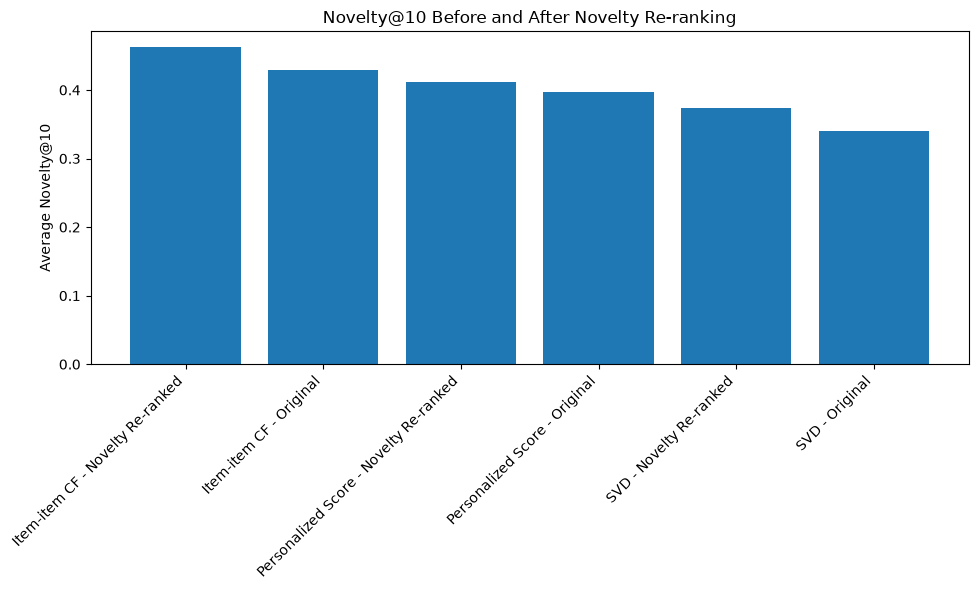

In [33]:
plot_data = summary_results[
    summary_results["model"].isin(["Personalized Score", "Item-item CF", "SVD"])
].copy()

plot_data["label"] = plot_data["model"] + " - " + plot_data["version"]

plt.figure(figsize=(10, 6))
plt.bar(plot_data["label"], plot_data["avg_novelty_at_10"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Novelty@10")
plt.title("Novelty@10 Before and After Novelty Re-ranking")
plt.tight_layout()
plt.show()

## Conclusion

This project was meant to compare several Spotify song recommendation approaches while also testing whether recommendations could be adjusted by novelty. The strongest model was the personalized score baseline. This original version had an average Precision@10 of 0.2270, Recall@10 of 0.9343, and NDCG@10 of 0.8377. Personalized score in the dataset was very good at ranking songs that appeared as relevant in the test data. The popularity baseline, Item Item collaborative filtering model, and SVD model performed much worse on the ranking metrics.

The weak performance of Item Item collaborative filtering and SVD is expected as these models rely on repeated user item patterns but this dataset was extremely sparse. Even after filtering there were 26252 rows, 1328 users, and 7020 songs, with a median of 7 interactions per user and 3 interactions per song. This was an was better than the original random samples but the matrix was still sparse for collaborative filtering and matrix factorization. It was unfortunate but many songs had low levels of interactions and the models had limited overlap to learn song similarities or create stable latent factors.

The novelty aware reranking method did increase the novelty of recommendations which was the goal but this of course sacrificed performance which may be acceptable in the case of improving novelty. The personalized score model’s Novelty@10 increased from 0.3969 to 0.4120 after reranking. Item Item collaborative filtering also increased from 0.4286 to 0.4624, and SVD increased from 0.3409 to 0.3737. This actually shows that the reranking process had a positive impact in successfully shifting recommendations toward less popular songsbut again this came with a small decrease in some accuracy metrics. For the personalized score model, Precision@10 decreased from 0.2270 to 0.2250, Recall@10 decreased from 0.9343 to 0.9291, and NDCG@10 decreased from 0.8377 to 0.8166. This is a natural expectation that further down your recommendations you may sacrifice NDGC and precision in order to promote novelty.

The results suggest that novelty can be added to a music recommender through reranking but the strength of the underlying recommendation model matters. In a real music platform, this suggests that novelty-aware recommendation may work best when we have more user and song metadata. This would have to be A/B tested in real life to see if these test results are replicated in a cohort of users. 